# Hyperspectral SegFormer MAE — Forward Pass Exploration

This notebook takes a real EnMAP scene, builds a vendable on the common 165-band grid, extracts a patch, and passes it through the untrained model to visualize what happens at each stage.

**No training has happened yet** — the model has random weights. The goal is to verify tensor shapes, understand the data flow, and see what raw (untrained) reconstructions look like.

In [1]:
import os, sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parents[0])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

torch.manual_seed(42)
np.random.seed(42)
DEVICE = "cpu"
print(f"Device: {DEVICE}")

Device: cpu


## 1. Build Vendable and Extract a Patch

Load an EnMAP scene, run the full pipeline (band filtering + spatial masking + interpolation + resampling to 165-band common grid), then extract a single 128x128 patch from a valid region.

In [2]:
from app.models.file_processing.sources import FileSourceConfig
from app.models.dataset.vendables import BandFilterConfig, DEFAULT_COMMON_WAVELENGTH_GRID
from app.utils.dataset_builder.enmap_dataset_builder import EnmapDatasetBuilder

SCENE = os.path.join(PROJECT_ROOT,
    "tests/test_payloads/ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z")

cfg = BandFilterConfig(common_wavelength_grid=DEFAULT_COMMON_WAVELENGTH_GRID)
builder = EnmapDatasetBuilder(file_source_configuration=FileSourceConfig(source_path=SCENE))
vendable = builder.vend_dataset(band_filter_config=cfg)

cube = vendable.normalized_hyperspectral_cube   # (165, H, W) float32
validity = vendable.validity_cube                # (165, H, W) int8
wavelengths = np.array(vendable.band_cw_order)   # (165,)

print(f"Vendable cube: {cube.shape}, validity: {validity.shape}")
print(f"Wavelengths: {wavelengths[0]:.0f}–{wavelengths[-1]:.0f} nm, {len(wavelengths)} bands")

# Find a patch where most pixels are valid
spatial_valid = validity[0]  # (H, W) — all bands agree
H, W = spatial_valid.shape

# Scan for a good 128x128 patch
best_r, best_c, best_frac = 0, 0, 0
for r in range(0, H - 128, 32):
    for c in range(0, W - 128, 32):
        frac = spatial_valid[r:r+128, c:c+128].mean()
        if frac > best_frac:
            best_r, best_c, best_frac = r, c, float(frac)

print(f"Best patch at ({best_r}, {best_c}), validity: {best_frac*100:.1f}%")

# Extract patch
patch_cube = cube[:, best_r:best_r+128, best_c:best_c+128].copy()      # (165, 128, 128)
patch_valid = validity[:, best_r:best_r+128, best_c:best_c+128].copy()  # (165, 128, 128)

# Convert to torch
x = torch.from_numpy(patch_cube).unsqueeze(0).float()       # (1, 165, 128, 128)
mask = torch.from_numpy(patch_valid[0:1]).unsqueeze(0).float()  # (1, 1, 128, 128)

print(f"\nPatch tensor: {x.shape}, mask: {mask.shape}")
print(f"Reflectance range: [{x.min():.4f}, {x.max():.4f}]")

Vendable cube: (165, 1179, 1320), validity: (165, 1179, 1320)
Wavelengths: 460–2450 nm, 165 bands
Best patch at (32, 256), validity: 100.0%

Patch tensor: torch.Size([1, 165, 128, 128]), mask: torch.Size([1, 1, 128, 128])
Reflectance range: [-0.0134, 0.5303]


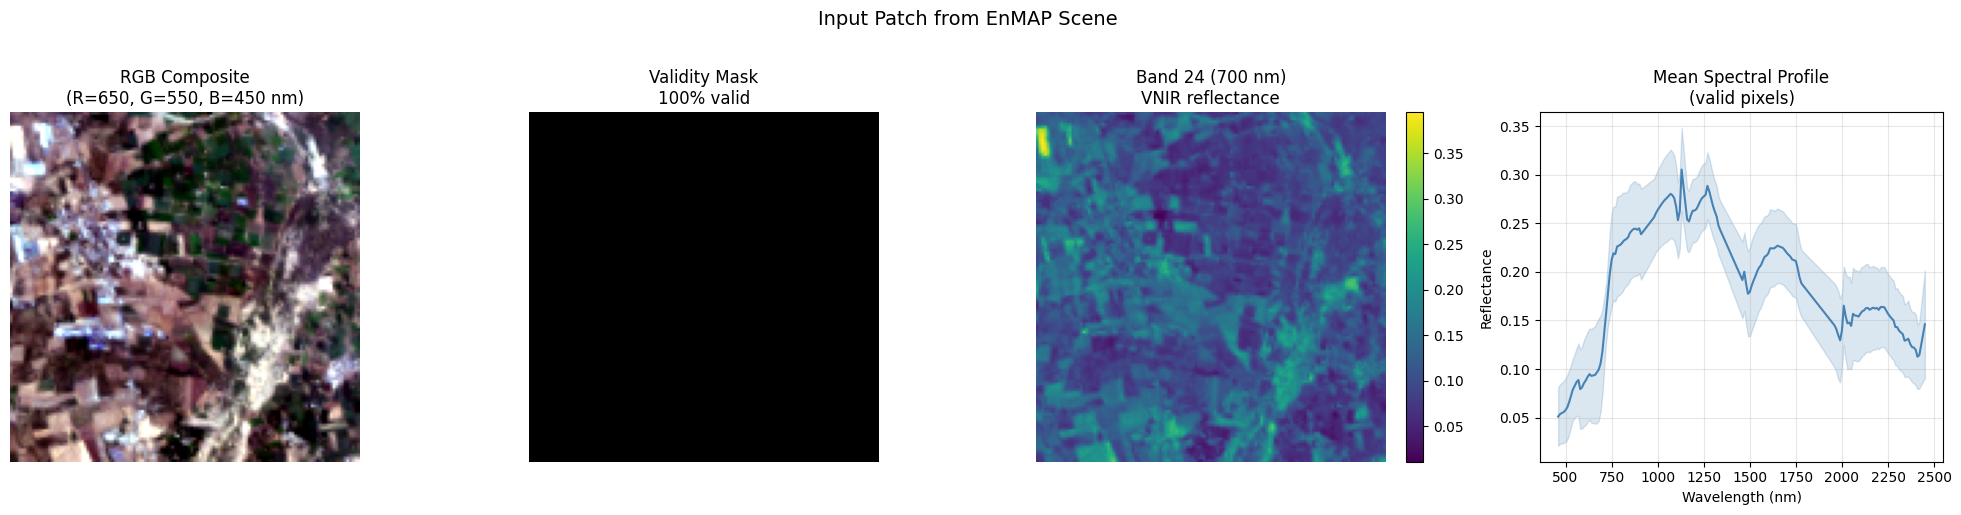

In [3]:
# Visualize the input patch
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# RGB composite
def make_rgb(cube, wl, validity=None):
    r = np.argmin(np.abs(wl - 650)); g = np.argmin(np.abs(wl - 550)); b = np.argmin(np.abs(wl - 450))
    rgb = np.stack([cube[r], cube[g], cube[b]], axis=-1).astype(np.float32)
    for ch in range(3):
        v = rgb[:,:,ch]; vals = v[v > 0] if validity is None else v[validity > 0]
        if len(vals) > 0:
            p2, p98 = np.percentile(vals, [2, 98])
            rgb[:,:,ch] = np.clip((v - p2) / (p98 - p2 + 1e-10), 0, 1)
    if validity is not None: rgb[validity == 0] = 0
    return rgb

sv = patch_valid[0]  # spatial validity (128, 128)
rgb = make_rgb(patch_cube, wavelengths, sv)
axes[0].imshow(rgb)
axes[0].set_title(f"RGB Composite\n(R=650, G=550, B=450 nm)")
axes[0].axis("off")

# Validity mask
axes[1].imshow(sv, cmap="gray")
axes[1].set_title(f"Validity Mask\n{sv.mean()*100:.0f}% valid")
axes[1].axis("off")

# Single band (VNIR ~700nm)
b_idx = np.argmin(np.abs(wavelengths - 700))
im = axes[2].imshow(np.ma.masked_where(sv == 0, patch_cube[b_idx]), cmap="viridis")
axes[2].set_title(f"Band {b_idx} ({wavelengths[b_idx]:.0f} nm)\nVNIR reflectance")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)

# Mean spectral profile (valid pixels only)
valid_spectra = patch_cube[:, sv == 1]  # (165, N)
mean_spec = valid_spectra.mean(axis=1)
std_spec = valid_spectra.std(axis=1)
axes[3].fill_between(wavelengths, mean_spec - std_spec, mean_spec + std_spec, alpha=0.2, color="steelblue")
axes[3].plot(wavelengths, mean_spec, color="steelblue", lw=1.5)
axes[3].set_xlabel("Wavelength (nm)"); axes[3].set_ylabel("Reflectance")
axes[3].set_title("Mean Spectral Profile\n(valid pixels)")
axes[3].grid(True, alpha=0.3)

plt.suptitle("Input Patch from EnMAP Scene", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Build the Model (Random Weights)

Create a HyperspectralSegFormerMAE with B0 config. Since we don't have real pixel stats yet, we'll compute approximate mean/std from this patch's valid pixels as a stand-in.

In [4]:
from app.foundation_models.components.hyperspectral_seg_former_mae import HyperspectralSegFormerMAE
from app.foundation_models.components.token_masking import TokenMasking
from app.foundation_models.components.sam_loss import SAMLoss

# Approximate per-band stats from this patch
fake_mean = valid_spectra.mean(axis=1).tolist()  # (165,)
fake_std = valid_spectra.std(axis=1).tolist()    # (165,)
fake_std = [max(s, 1e-6) for s in fake_std]     # avoid div-by-zero

model = HyperspectralSegFormerMAE(
    in_channels=165,
    compressed_channels=24,
    embed_dims=[32, 64, 160, 256],
    num_heads=[1, 2, 5, 8],
    reduction_ratios=[8, 4, 2, 1],
    num_blocks=[2, 2, 2, 2],
    decoder_dim=256,
    drop_rate=0.0,  # no dropout for exploration
    pixel_mean=fake_mean,
    pixel_std=fake_std,
)
model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: HyperspectralSegFormerMAE B0")
print(f"Total parameters: {total_params:,}")
print(f"  Compressor (165→24):  {sum(p.numel() for p in model.compressor.parameters()):,}")
print(f"  Encoder:              {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Decoder:              {sum(p.numel() for p in model.decoder.parameters()):,}")
print(f"  Decompressor (24→165):{sum(p.numel() for p in model.decompressor.parameters()):,}")

Model: HyperspectralSegFormerMAE B0
Total parameters: 5,204,829
  Compressor (165→24):  4,032
  Encoder:              3,326,976
  Decoder:              1,869,696
  Decompressor (24→165):4,125


## 3. Step-by-Step Forward Pass (No Masking)

Pass the patch through the model without MAE masking to see the full reconstruction from random weights. We'll intercept intermediate tensors to visualize each stage.

In [5]:
with torch.no_grad():
    # Step 1: Mask invalid pixels
    x_masked = x * mask
    print(f"1. After validity masking:  {x_masked.shape}")

    # Step 2: Normalize
    x_norm = model.normalize(x_masked)
    print(f"2. After normalization:     {x_norm.shape}")
    print(f"   Valid pixel range: [{x_norm[mask.expand_as(x_norm) == 1].min():.2f}, {x_norm[mask.expand_as(x_norm) == 1].max():.2f}]")
    print(f"   Invalid pixel val:  ~{x_norm[0, 0, sv == 0].mean():.2f} (band 0)")

    # Step 3: Spectral compression
    x_compressed = model.compressor(x_norm)
    print(f"3. After compression:       {x_compressed.shape}  (165 → 24 channels)")

    # Step 4: Encoder
    features = model.encoder(x_compressed, keep_mask=None)
    for i, f in enumerate(features):
        print(f"4. Encoder F{i+1}:             {f.shape}")

    # Step 5: Decoder
    x_decoded = model.decoder(features)
    print(f"5. After decoder:           {x_decoded.shape}  (back to 24 channels, full res)")

    # Step 6: Spectral decompression
    x_decompressed = model.decompressor(x_decoded)
    print(f"6. After decompression:     {x_decompressed.shape}  (24 → 165 channels)")

    # Step 7: Denormalize
    x_hat = model.denormalize(x_decompressed)
    print(f"7. After denormalization:   {x_hat.shape}  (back to reflectance)")

    # Full forward pass for verification
    x_hat_full = model(x, mask=mask)
    print(f"\nFull forward match: {torch.allclose(x_hat, x_hat_full, atol=1e-5)}")

1. After validity masking:  torch.Size([1, 165, 128, 128])
2. After normalization:     torch.Size([1, 165, 128, 128])
   Valid pixel range: [-4.70, 11.74]
   Invalid pixel val:  ~nan (band 0)
3. After compression:       torch.Size([1, 24, 128, 128])  (165 → 24 channels)
4. Encoder F1:             torch.Size([1, 32, 32, 32])
4. Encoder F2:             torch.Size([1, 64, 16, 16])
4. Encoder F3:             torch.Size([1, 160, 8, 8])
4. Encoder F4:             torch.Size([1, 256, 4, 4])
5. After decoder:           torch.Size([1, 24, 128, 128])  (back to 24 channels, full res)
6. After decompression:     torch.Size([1, 165, 128, 128])  (24 → 165 channels)
7. After denormalization:   torch.Size([1, 165, 128, 128])  (back to reflectance)

Full forward match: True


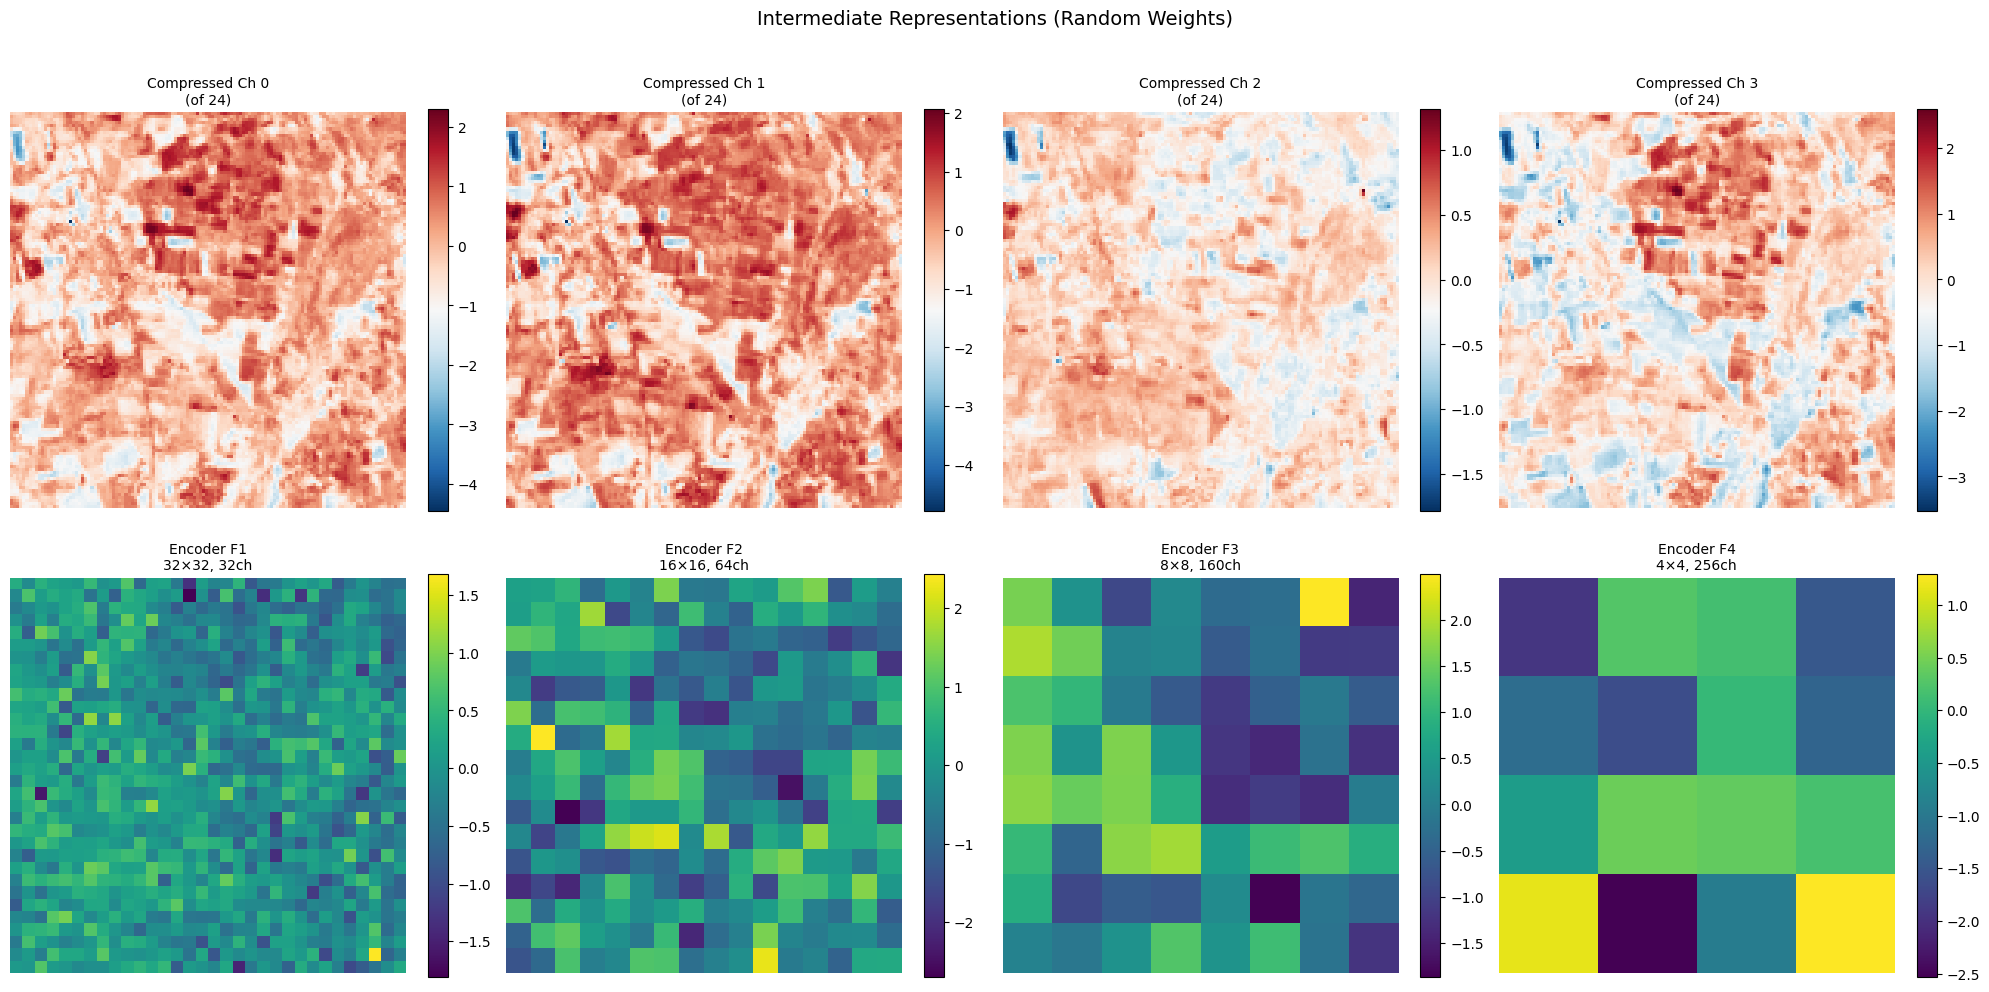

In [6]:
# Visualize intermediate representations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Compressed channels (first 4 of 24)
for i in range(4):
    im = axes[0, i].imshow(x_compressed[0, i].numpy(), cmap="RdBu_r")
    axes[0, i].set_title(f"Compressed Ch {i}\n(of 24)", fontsize=10)
    axes[0, i].axis("off")
    plt.colorbar(im, ax=axes[0, i], fraction=0.046)

# Row 2: Encoder feature maps (one channel from each stage)
for i, f in enumerate(features):
    im = axes[1, i].imshow(f[0, 0].numpy(), cmap="viridis")
    axes[1, i].set_title(f"Encoder F{i+1}\n{f.shape[2]}×{f.shape[3]}, {f.shape[1]}ch", fontsize=10)
    axes[1, i].axis("off")
    plt.colorbar(im, ax=axes[1, i], fraction=0.046)

plt.suptitle("Intermediate Representations (Random Weights)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Input vs Reconstruction (No Masking, Random Weights)

Compare the original patch to what the untrained model produces. With random weights the reconstruction should look like noise — no learned structure yet.

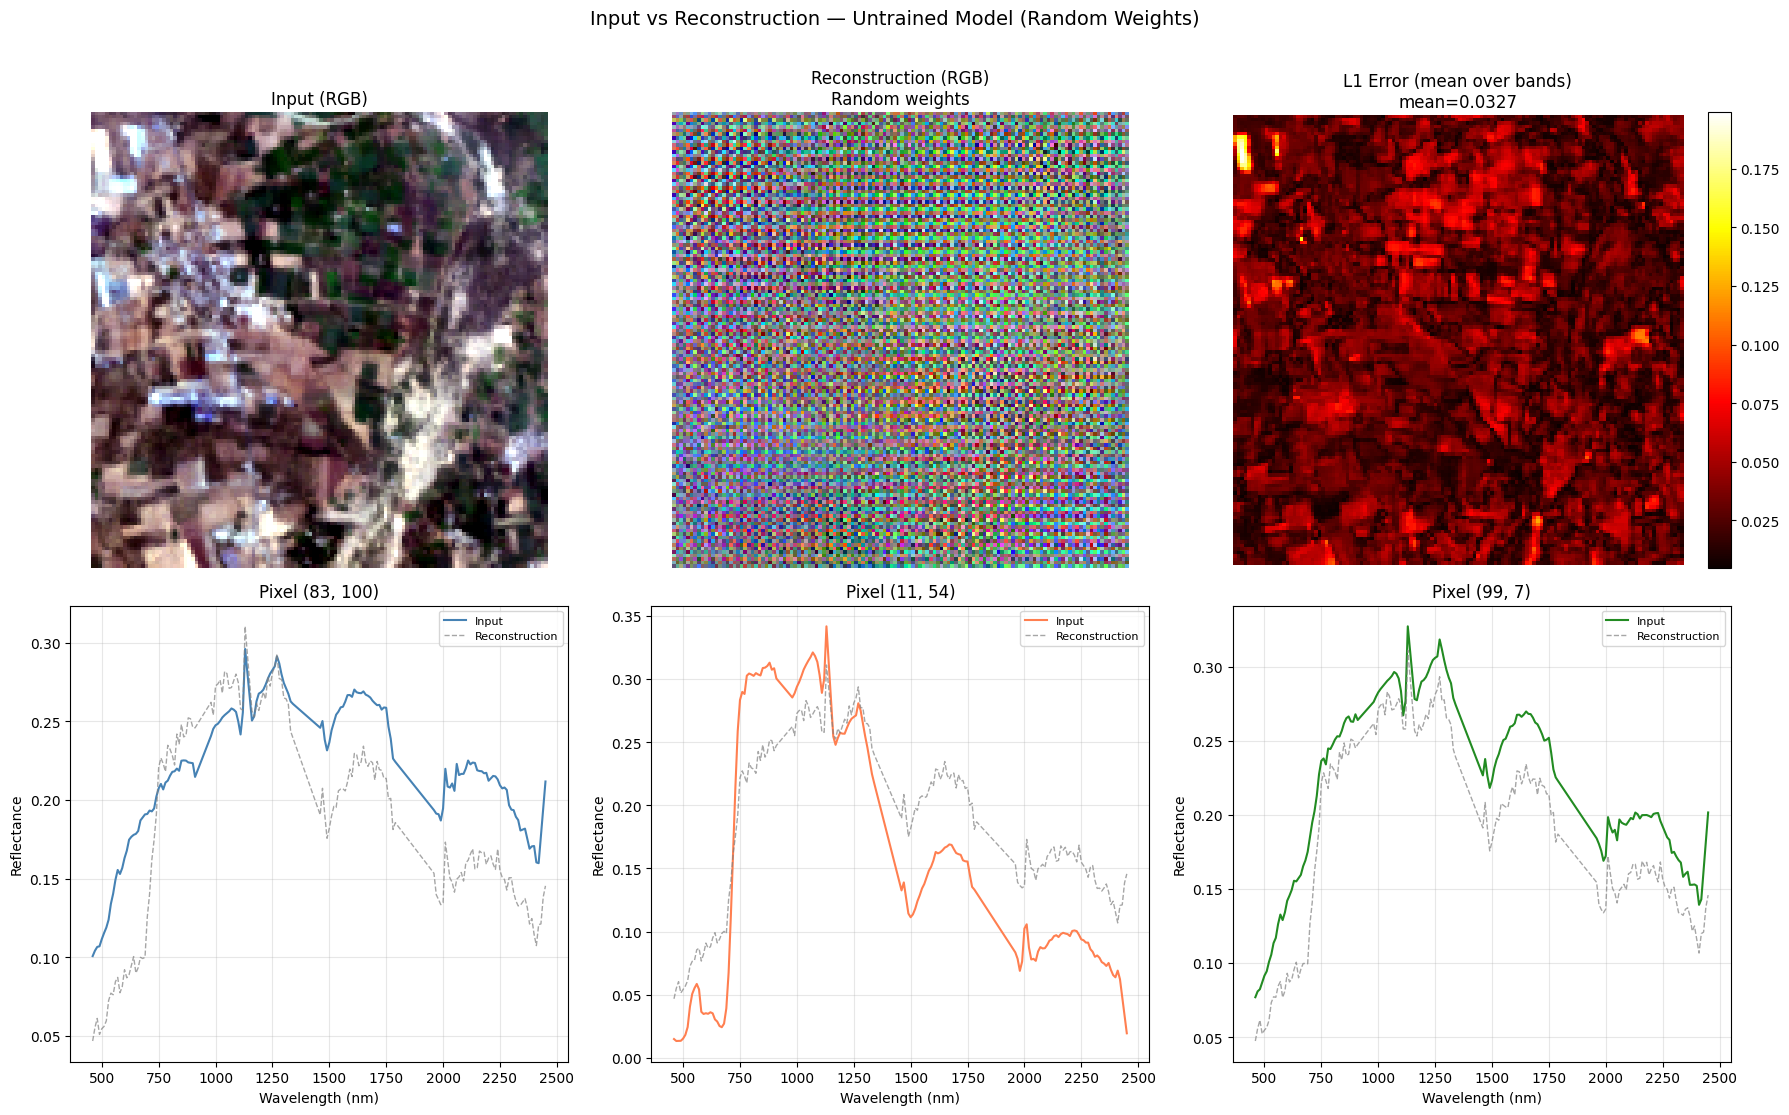

In [7]:
x_hat_np = x_hat[0].numpy()  # (165, 128, 128)
x_np = x[0].numpy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 1: RGB — input, reconstruction, difference
rgb_input = make_rgb(x_np, wavelengths, sv)
rgb_recon = make_rgb(x_hat_np, wavelengths, sv)

axes[0, 0].imshow(rgb_input); axes[0, 0].set_title("Input (RGB)"); axes[0, 0].axis("off")
axes[0, 1].imshow(rgb_recon); axes[0, 1].set_title("Reconstruction (RGB)\nRandom weights"); axes[0, 1].axis("off")

# Per-pixel L1 error (mean across bands)
l1_error = np.abs(x_hat_np - x_np).mean(axis=0)  # (128, 128)
l1_error_masked = np.ma.masked_where(sv == 0, l1_error)
im = axes[0, 2].imshow(l1_error_masked, cmap="hot")
axes[0, 2].set_title(f"L1 Error (mean over bands)\nmean={l1_error[sv==1].mean():.4f}")
axes[0, 2].axis("off")
plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

# Row 2: Spectral comparison at 3 random valid pixels
rng = np.random.default_rng(42)
valid_px = np.argwhere(sv == 1)
sample_px = valid_px[rng.choice(len(valid_px), 3, replace=False)]
colors = ["steelblue", "coral", "forestgreen"]

for idx, (px, col) in enumerate(zip(sample_px, colors)):
    r, c = px
    spec_in = x_np[:, r, c]
    spec_out = x_hat_np[:, r, c]
    axes[1, idx].plot(wavelengths, spec_in, color=col, lw=1.5, label="Input")
    axes[1, idx].plot(wavelengths, spec_out, color="gray", lw=1, alpha=0.7, linestyle="--", label="Reconstruction")
    axes[1, idx].set_xlabel("Wavelength (nm)")
    axes[1, idx].set_ylabel("Reflectance")
    axes[1, idx].set_title(f"Pixel ({r}, {c})")
    axes[1, idx].legend(fontsize=8)
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle("Input vs Reconstruction — Untrained Model (Random Weights)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. MAE Forward Pass — With Token Removal

Now apply the actual MAE masking: remove 50% of valid tokens at Stage 1, reconstruct, and see the effect. We'll visualize which tokens were masked, the encoder features with "holes", and the reconstruction.

Tokens: 1024 total, 1024 valid, 512 kept, 512 prediction targets
Mask ratio: 50% of valid tokens


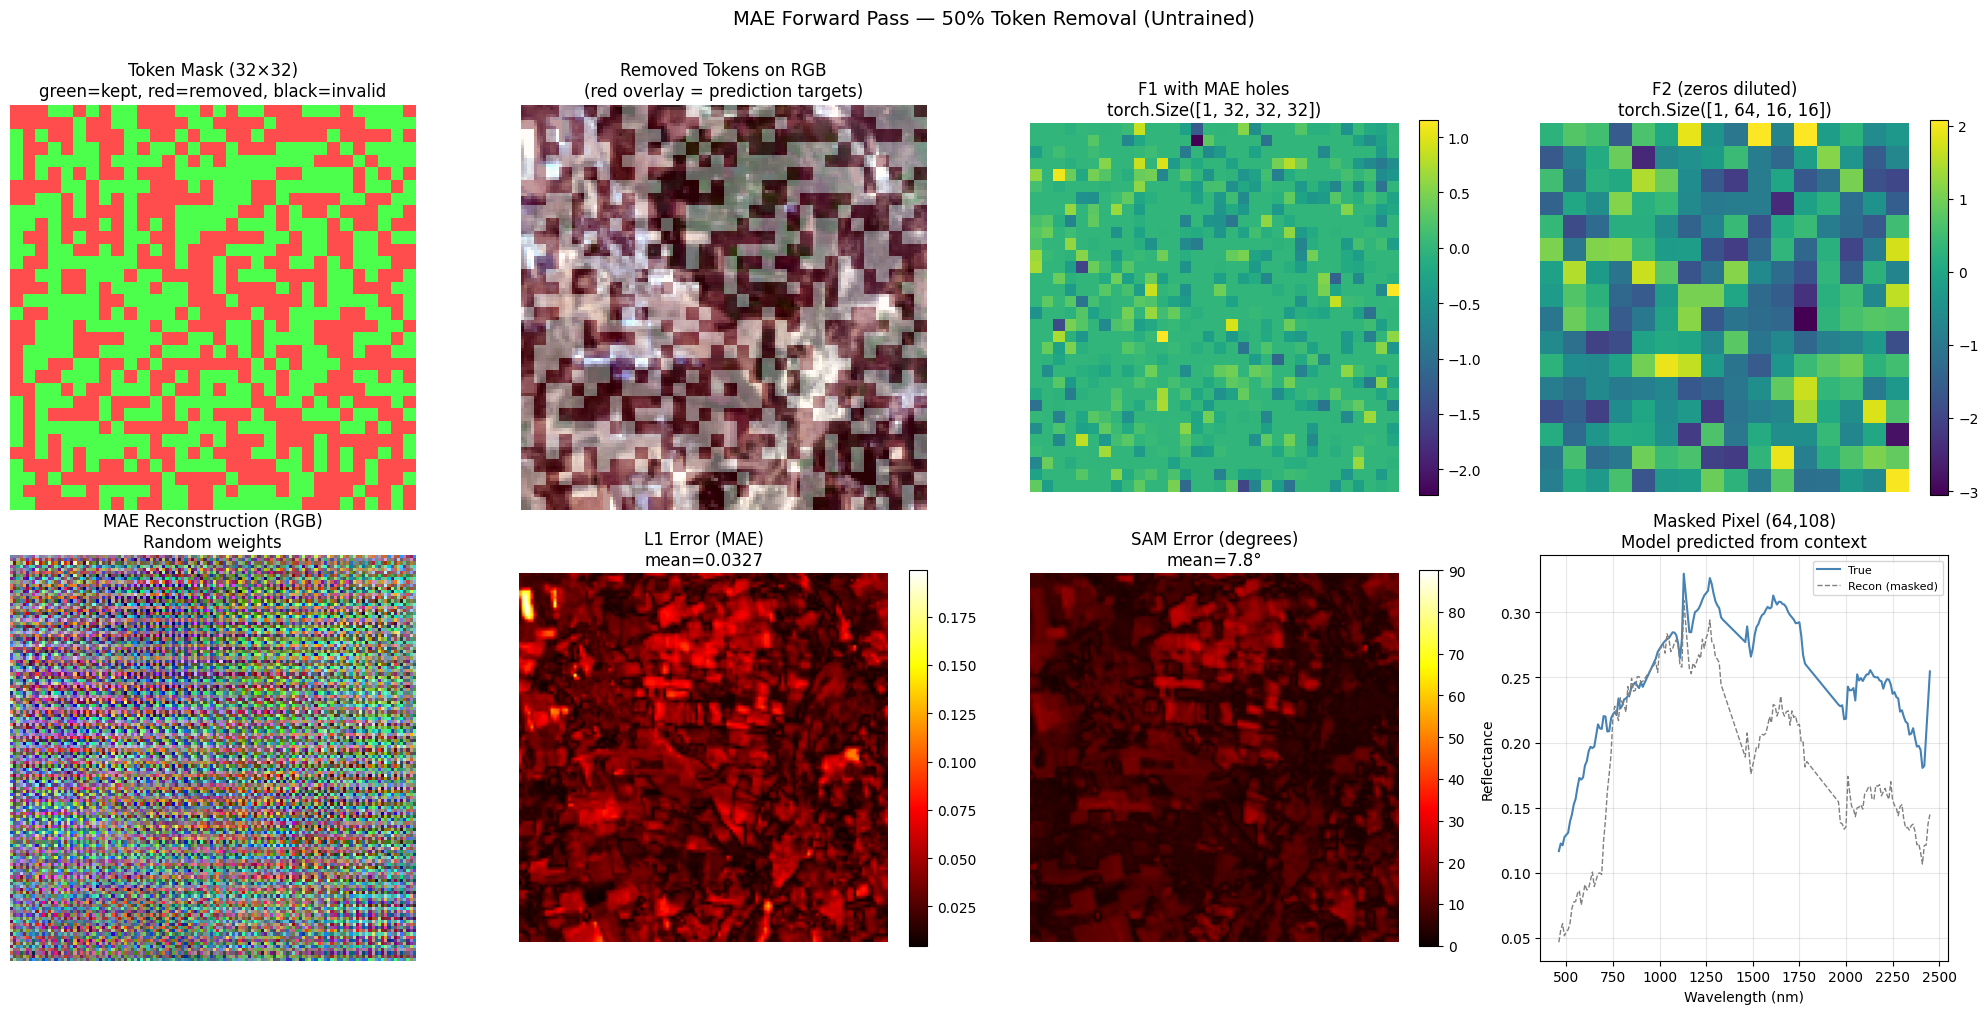

In [8]:
MASK_RATIO = 0.5

with torch.no_grad():
    # Build token-level masks
    token_mask = TokenMasking.pixel_mask_to_token_mask(
        mask, kernel_size=4, stride=4, padding=0
    )
    keep_mask, pred_mask = TokenMasking.generate_prediction_mask(
        token_mask, MASK_RATIO, DEVICE
    )

    N = token_mask.shape[1]
    n_valid = int(token_mask.sum())
    n_kept = int(keep_mask.sum())
    n_pred = int(pred_mask.sum())

    print(f"Tokens: {N} total, {n_valid} valid, {n_kept} kept, {n_pred} prediction targets")
    print(f"Mask ratio: {n_pred / n_valid * 100:.0f}% of valid tokens")

    # Forward with MAE
    x_hat_mae = model(x, mask=mask, keep_mask=keep_mask)

    # Also get encoder features WITH masking to see the holes
    x_mae_norm = model.normalize(x * mask)
    x_mae_comp = model.compressor(x_mae_norm)
    features_mae = model.encoder(x_mae_comp, keep_mask=keep_mask)

# Visualize the token mask as a spatial grid
pred_grid = pred_mask[0].reshape(32, 32).numpy()  # (32, 32) — prediction targets
keep_grid = keep_mask[0].reshape(32, 32).numpy()   # (32, 32) — kept tokens
token_valid_grid = token_mask[0].reshape(32, 32).numpy()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Token masks + F1 with holes
# Token validity
display = np.zeros((32, 32, 3))
display[token_valid_grid == 1] = [0.3, 0.3, 0.3]  # valid = gray
display[pred_grid == 1] = [1, 0.3, 0.3]            # prediction targets = red
display[keep_grid == 1] = [0.3, 1, 0.3]            # kept = green
axes[0, 0].imshow(display, interpolation="nearest")
axes[0, 0].set_title(f"Token Mask (32×32)\ngreen=kept, red=removed, black=invalid")
axes[0, 0].axis("off")

# Upscale to pixel level
pixel_pred = pred_grid.repeat(4, axis=0).repeat(4, axis=1)  # (128, 128)
axes[0, 1].imshow(rgb_input)
axes[0, 1].imshow(pixel_pred, alpha=0.4, cmap="Reds")
axes[0, 1].set_title("Removed Tokens on RGB\n(red overlay = prediction targets)")
axes[0, 1].axis("off")

# F1 with holes (channel 0)
im = axes[0, 2].imshow(features_mae[0][0, 0].numpy(), cmap="viridis")
axes[0, 2].set_title(f"F1 with MAE holes\n{features_mae[0].shape}")
axes[0, 2].axis("off")
plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

# F2 (zeros are diluted by overlapping conv)
im = axes[0, 3].imshow(features_mae[1][0, 0].numpy(), cmap="viridis")
axes[0, 3].set_title(f"F2 (zeros diluted)\n{features_mae[1].shape}")
axes[0, 3].axis("off")
plt.colorbar(im, ax=axes[0, 3], fraction=0.046)

# Row 2: MAE reconstruction
rgb_mae = make_rgb(x_hat_mae[0].numpy(), wavelengths, sv)
axes[1, 0].imshow(rgb_mae)
axes[1, 0].set_title("MAE Reconstruction (RGB)\nRandom weights")
axes[1, 0].axis("off")

# L1 error map
l1_mae = np.abs(x_hat_mae[0].numpy() - x_np).mean(axis=0)
l1_mae_masked = np.ma.masked_where(sv == 0, l1_mae)
im = axes[1, 1].imshow(l1_mae_masked, cmap="hot")
axes[1, 1].set_title(f"L1 Error (MAE)\nmean={l1_mae[sv==1].mean():.4f}")
axes[1, 1].axis("off")
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

# SAM map
dot = (x_hat_mae[0].numpy() * x_np * sv[None]).sum(axis=0)
norm_hat = np.sqrt((x_hat_mae[0].numpy()**2 * sv[None]).sum(axis=0))
norm_x = np.sqrt((x_np**2 * sv[None]).sum(axis=0))
cos_sim = np.clip(dot / (norm_hat * norm_x + 1e-8), -1, 1)
sam_map = np.arccos(cos_sim) * 180 / np.pi  # degrees
sam_masked = np.ma.masked_where(sv == 0, sam_map)
im = axes[1, 2].imshow(sam_masked, cmap="hot", vmin=0, vmax=90)
axes[1, 2].set_title(f"SAM Error (degrees)\nmean={sam_map[sv==1].mean():.1f}°")
axes[1, 2].axis("off")
plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

# Spectral comparison at a masked pixel
pred_pixels = np.argwhere((pixel_pred == 1) & (sv == 1))
if len(pred_pixels) > 0:
    r, c = pred_pixels[len(pred_pixels)//2]
    axes[1, 3].plot(wavelengths, x_np[:, r, c], color="steelblue", lw=1.5, label="True")
    axes[1, 3].plot(wavelengths, x_hat_mae[0, :, r, c].numpy(), color="gray", lw=1, linestyle="--", label="Recon (masked)")
    axes[1, 3].set_xlabel("Wavelength (nm)")
    axes[1, 3].set_ylabel("Reflectance")
    axes[1, 3].set_title(f"Masked Pixel ({r},{c})\nModel predicted from context")
    axes[1, 3].legend(fontsize=8)
    axes[1, 3].grid(True, alpha=0.3)

plt.suptitle("MAE Forward Pass — 50% Token Removal (Untrained)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Loss Computation

Compute the combined L1 + SAM loss at masked valid positions, exactly as the trainer would during training. Also visualize the SAM ramp schedule.

Loss mask: 8192 pixels (of 16384 total)

L1 loss (masked valid): 0.0330
SAM loss (masked valid): 0.1371 rad (7.9°)

Combined loss with SAM ramp (sam_weight=1.0, ramp_epochs=20):
   Epoch     λ(t)         L1        SAM   Combined
--------------------------------------------------
       0     0.00     0.0330     0.1371     0.0330
       5     0.25     0.0330     0.1371     0.0673
      10     0.50     0.0330     0.1371     0.1015
      15     0.75     0.0330     0.1371     0.1358
      20     1.00     0.0330     0.1371     0.1701
      50     1.00     0.0330     0.1371     0.1701
     100     1.00     0.0330     0.1371     0.1701


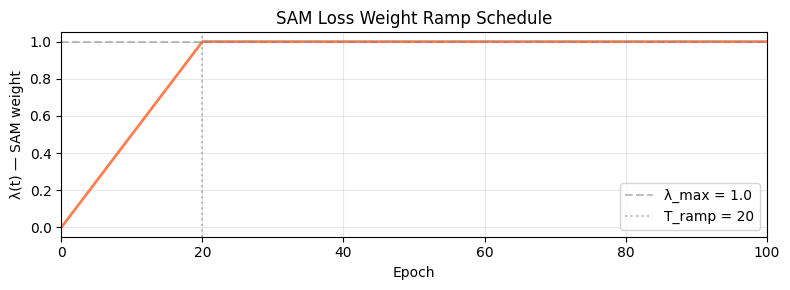

In [9]:
sam_loss_fn = SAMLoss()

with torch.no_grad():
    # Build pixel-level prediction mask (same as trainer does)
    H_t, W_t = 32, 32
    pixel_pred_mask = pred_mask.reshape(1, 1, H_t, W_t)
    pixel_pred_mask = torch.nn.functional.interpolate(pixel_pred_mask, size=(128, 128), mode="nearest")

    # Eroded validity
    eroded_mask = TokenMasking.erode_mask(mask, kernel_size=1)

    # Loss mask = prediction targets × valid × interior
    loss_mask = pixel_pred_mask * eroded_mask
    n_loss_pixels = int(loss_mask.sum())

    print(f"Loss mask: {n_loss_pixels} pixels (of {128*128} total)")
    print()

    # L1 loss
    per_pixel_l1 = (x_hat_mae - x).abs().mean(dim=1, keepdim=True)
    valid_l1 = per_pixel_l1[loss_mask == 1]
    l1_val = valid_l1.mean().item()
    print(f"L1 loss (masked valid): {l1_val:.4f}")

    # SAM loss
    sam_val = sam_loss_fn(x_hat_mae, x, loss_mask)
    print(f"SAM loss (masked valid): {sam_val.item():.4f} rad ({sam_val.item()*180/3.14159:.1f}°)")

    # Combined at various epochs (showing the ramp)
    print(f"\nCombined loss with SAM ramp (sam_weight=1.0, ramp_epochs=20):")
    print(f"{'Epoch':>8} {'λ(t)':>8} {'L1':>10} {'SAM':>10} {'Combined':>10}")
    print(f"{'-'*50}")
    for epoch in [0, 5, 10, 15, 20, 50, 100]:
        lam = 1.0 * min(1.0, epoch / 20)
        combined = l1_val + lam * sam_val.item()
        print(f"{epoch:>8d} {lam:>8.2f} {l1_val:>10.4f} {sam_val.item():>10.4f} {combined:>10.4f}")

# SAM ramp schedule plot
fig, ax = plt.subplots(figsize=(8, 3))
epochs = np.arange(0, 500)
lam = np.minimum(1.0, epochs / 20) * 1.0
ax.plot(epochs, lam, color="coral", lw=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("λ(t) — SAM weight")
ax.set_title("SAM Loss Weight Ramp Schedule")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="λ_max = 1.0")
ax.axvline(20, color="gray", linestyle=":", alpha=0.5, label="T_ramp = 20")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 100])
plt.tight_layout()
plt.show()

## 7. What the Compressor Learned (Random Weights)

Inspect the spectral compressor's weight matrix — it's a (24×165) matrix that projects each pixel's 165-band spectrum into 24 compressed dimensions. With random weights, the "basis vectors" are random directions. After training, they should resemble MNF components — ordered by information content for reconstruction.

Compressor weight: (24, 165)  — 24 spectral basis vectors of length 165
Decompressor weight: (165, 24)  — inverse projection


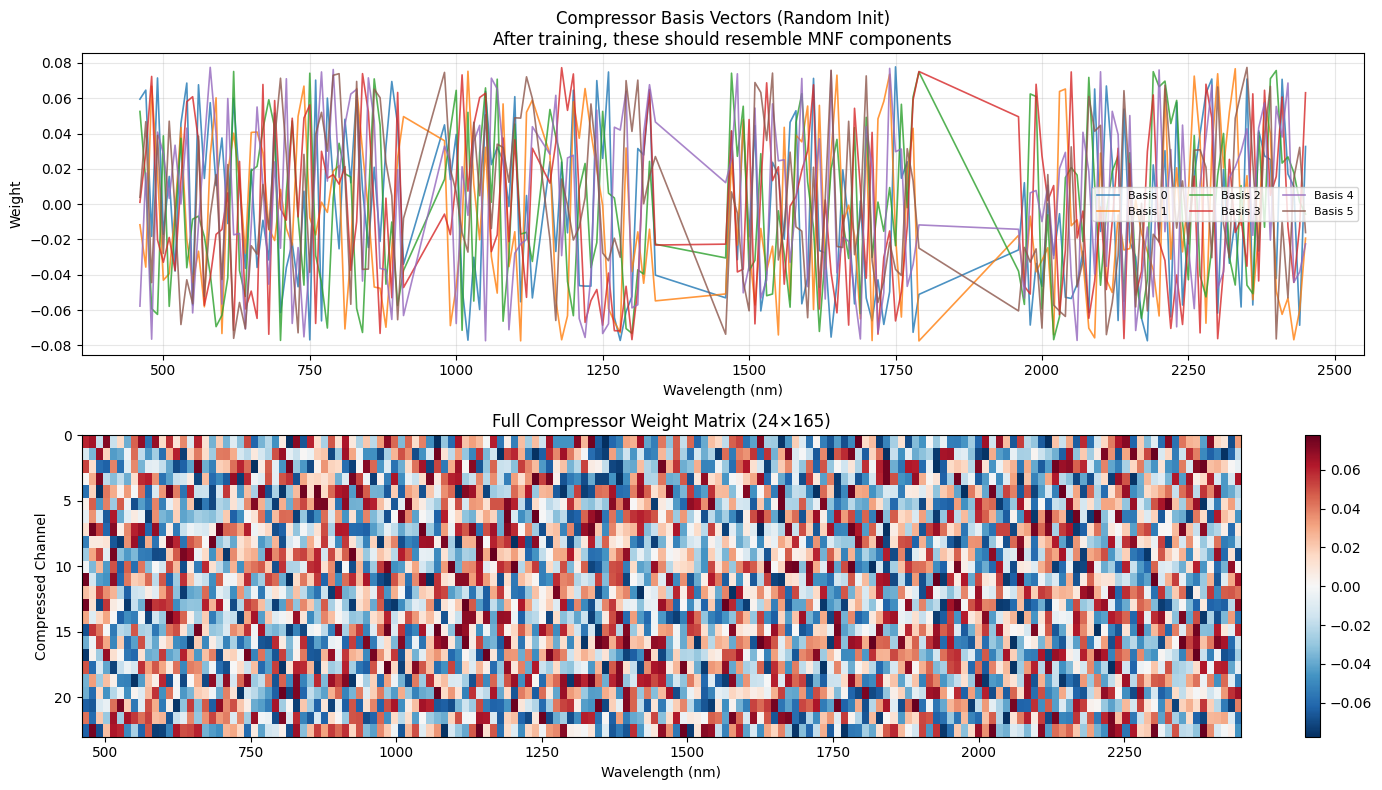


Roundtrip matrix (decomp @ comp): (165, 165)
Diagonal mean: -0.0002 (ideal: 1.0 after training)
Off-diagonal abs mean: 0.0202 (ideal: 0.0)


In [10]:
# The compressor weight is (24, 165, 1, 1) — squeeze to (24, 165)
W_comp = model.compressor.compress.weight.data.squeeze().numpy()  # (24, 165)
W_decomp = model.decompressor.decompress.weight.data.squeeze().numpy()  # (165, 24)

print(f"Compressor weight: {W_comp.shape}  — 24 spectral basis vectors of length 165")
print(f"Decompressor weight: {W_decomp.shape}  — inverse projection")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot first 6 compressor basis vectors as spectral profiles
for i in range(6):
    axes[0].plot(wavelengths, W_comp[i], lw=1.2, alpha=0.8, label=f"Basis {i}")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Weight")
axes[0].set_title("Compressor Basis Vectors (Random Init)\nAfter training, these should resemble MNF components")
axes[0].legend(fontsize=8, ncol=3)
axes[0].grid(True, alpha=0.3)

# Heatmap of full weight matrix
im = axes[1].imshow(W_comp, aspect="auto", cmap="RdBu_r",
                     extent=[wavelengths[0], wavelengths[-1], 23, 0])
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Compressed Channel")
axes[1].set_title("Full Compressor Weight Matrix (24×165)")
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

# Roundtrip test: compress then decompress
roundtrip = W_decomp @ W_comp  # (165, 165) — should be ~identity after training
print(f"\nRoundtrip matrix (decomp @ comp): {roundtrip.shape}")
print(f"Diagonal mean: {np.diag(roundtrip).mean():.4f} (ideal: 1.0 after training)")
print(f"Off-diagonal abs mean: {np.abs(roundtrip - np.diag(np.diag(roundtrip))).mean():.4f} (ideal: 0.0)")

## 8. Summary

What we've verified:
1. **Data flow**: EnMAP scene → 165-band vendable → 128×128 patch → model input
2. **Spectral compression**: 165 → 24 channels via learned 1×1 conv (4K params)
3. **Token removal**: 50% of valid tokens physically removed at Stage 1 (gather/scatter)
4. **Encoder features**: F1 shows holes from masking, F2 onward diluted by overlapping convs
5. **Decoder**: PixelShuffle reconstructs from 24 compressed channels back to full resolution
6. **Spectral decompression**: 24 → 165 channels, no activation
7. **Loss**: L1 (magnitude) + SAM (spectral angle) at masked valid positions, with SAM ramp
8. **Compressor weights**: Random init — after training these become the learned spectral basis

**Next steps**: Generate shards on EC2, compute real pixel stats, train the model, then revisit this notebook with trained weights to see meaningful reconstructions.